# Question 7: Smoothing Spline with k-Fold Cross-Validation
## Boston Dataset Analysis

**Objective:** Use k-fold cross-validation to find the best choice of degrees of freedom (df) for applying smoothing spline on the Boston dataset.

**Response (Y):** medv (median house value)
**Predictor (X):** lstat (lower status of the population)

## Import Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from patsy import dmatrix # constructs design matrix for B-spline basis
import statsmodels.api as sm

import warnings
warnings.filterwarnings('ignore')

## Step 1: Load the Boston Dataset from CSV

In [2]:
# Load Boston dataset from CSV file
boston_df = pd.read_csv('Boston.csv')

print("Boston Dataset loaded successfully!")
print(f"Shape: {boston_df.shape}")
print(f"Columns: {boston_df.columns.tolist()}")
print("\nFirst few rows:")
print(boston_df.head())
print("\nDataset Info:")
print(boston_df[['lstat', 'medv']].describe())

Boston Dataset loaded successfully!
Shape: (506, 15)
Columns: ['Unnamed: 0', 'crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax', 'ptratio', 'black', 'lstat', 'medv']

First few rows:
   Unnamed: 0     crim    zn  indus  chas    nox     rm   age     dis  rad  \
0           1  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1   
1           2  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2   
2           3  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2   
3           4  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3   
4           5  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3   

   tax  ptratio   black  lstat  medv  
0  296     15.3  396.90   4.98  24.0  
1  242     17.8  396.90   9.14  21.6  
2  242     17.8  392.83   4.03  34.7  
3  222     18.7  394.63   2.94  33.4  
4  222     18.7  396.90   5.33  36.2  

Dataset Info:
            lstat        medv
count  506.000000  506.000000
mean    12.653063  

## Step 2: Extract Predictor (lstat) and Response (medv)

In [3]:
# Extract X (lstat) and y (medv)
X = boston_df['lstat'].values
y = boston_df['medv'].values

print(f"Predictor (lstat) shape: {X.shape}")
print(f"Response (medv) shape: {y.shape}")
print(f"\nlstat range: [{X.min():.2f}, {X.max():.2f}]")
print(f"medv range: [{y.min():.2f}, {y.max():.2f}]")
print(f"\nCorrelation (lstat, medv): {np.corrcoef(X, y)[0, 1]:.4f}")
print(f"Number of observations: {len(X)}")

Predictor (lstat) shape: (506,)
Response (medv) shape: (506,)

lstat range: [1.73, 37.97]
medv range: [5.00, 50.00]

Correlation (lstat, medv): -0.7377
Number of observations: 506


## Step 3: Visualize the Data

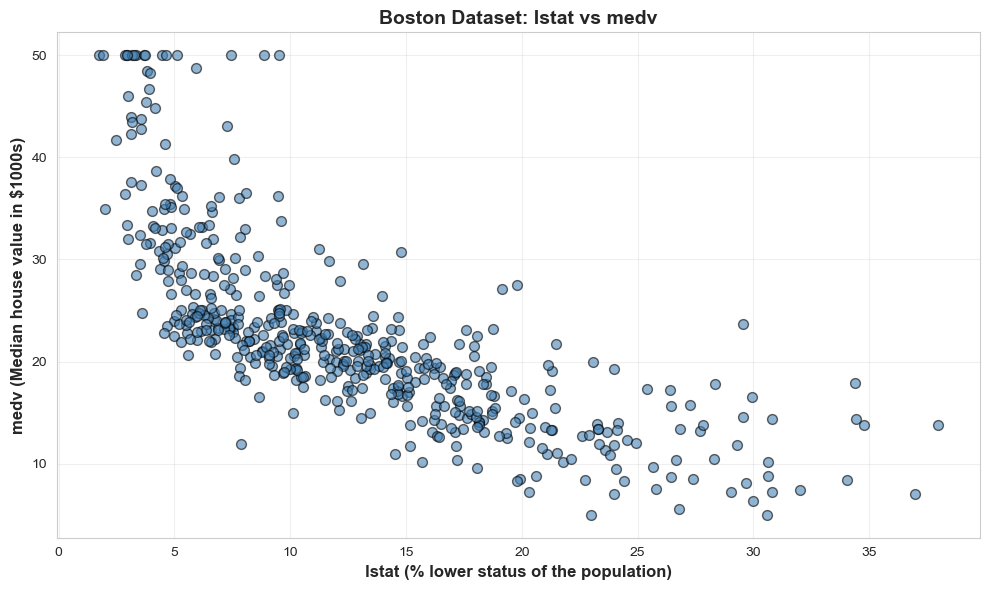

The negative correlation (-0.7377) indicates that
lower-status percentage is inversely related to median house values.


In [4]:
# Plot scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(X, y, marker='o', alpha=0.6, edgecolors='k', s=50, color='steelblue')
plt.xlabel('lstat (% lower status of the population)', fontsize=12, fontweight='bold')
plt.ylabel('medv (Median house value in $1000s)', fontsize=12, fontweight='bold')
plt.title('Boston Dataset: lstat vs medv', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"The negative correlation ({np.corrcoef(X, y)[0, 1]:.4f}) indicates that")
print("lower-status percentage is inversely related to median house values.")

## Step 4: K-Fold Cross-Validation Setup

We'll use 5-fold cross-validation to evaluate different degrees of freedom (df) values using B-spline basis

In [5]:
# Define degrees of freedom to test
df_values = [4, 5, 10, 20, 30, 40, 50]

# Initialize k-fold cross-validation
k_folds = 5  # 5-fold cross-validation
kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)

# Store cross-validation errors for each fold
cv_results = {}
for df in df_values:
    cv_results[df] = {'train_errors': [], 'test_errors': []}

print(f"Starting {k_folds}-fold cross-validation...")
print(f"Testing degrees of freedom: {df_values}")
print(f"Total folds: {k_folds}")
print(f"B-spline basis with include_intercept=False\n")

Starting 5-fold cross-validation...
Testing degrees of freedom: [4, 5, 10, 20, 30, 40, 50]
Total folds: 5
B-spline basis with include_intercept=False



## Step 5: Perform K-Fold Cross-Validation with B-Spline Basis

In [6]:
# Create a dataframe for X to use with patsy
data_df = pd.DataFrame({'X': X, 'y': y})

fold_num = 0
for train_idx, test_idx in kf.split(X):
    fold_num += 1
    print(f"Fold {fold_num}/{k_folds}:", end=" ")
    
    # Extract train and test data for this fold
    X_train_fold = X[train_idx]
    y_train_fold = y[train_idx]
    X_test_fold = X[test_idx]
    y_test_fold = y[test_idx]
    
    # Create dataframes for patsy
    train_data = pd.DataFrame({'X': X_train_fold, 'y': y_train_fold})
    test_data = pd.DataFrame({'X': X_test_fold, 'y': y_test_fold})
    
    print(f"Train: {len(train_idx)}, Test: {len(test_idx)} | ", end="")
    
    for k in df_values:
        try:
            # Create B-spline design matrix for training data
            X_spline_train = dmatrix(f"bs(X, df={k}, include_intercept=False)", 
                                     data=train_data, return_type='dataframe')
            
            # Fit OLS model on training data
            model = sm.OLS(y_train_fold, X_spline_train).fit()
            
            # Predict on training data
            y_train_pred = model.predict(X_spline_train)
            train_mse = mean_squared_error(y_train_fold, y_train_pred)
            cv_results[k]['train_errors'].append(train_mse)
            
            # Create B-spline design matrix for test data (using same knots as training)
            X_spline_test = dmatrix(f"bs(X, df={k}, include_intercept=False)", 
                                    data=test_data, return_type='dataframe')
            
            # Predict on test data
            y_test_pred = model.predict(X_spline_test)
            test_mse = mean_squared_error(y_test_fold, y_test_pred)
            cv_results[k]['test_errors'].append(test_mse)
            
        except Exception as e:
            print(f"Error with df={k}: {e}")
    
    print("done")

print(f"\n✓ Cross-validation completed!")

Fold 1/5: Train: 404, Test: 102 | done
Fold 2/5: Train: 405, Test: 101 | done
Fold 3/5: Train: 405, Test: 101 | done
Fold 4/5: Train: 405, Test: 101 | done
Fold 5/5: Train: 405, Test: 101 | done

✓ Cross-validation completed!


## Step 6: Compute Average Cross-Validation Errors

In [7]:
# Calculate average and standard deviation of errors
avg_train_errors = [np.mean(cv_results[df]['train_errors']) for df in df_values]
std_train_errors = [np.std(cv_results[df]['train_errors']) for df in df_values]
avg_test_errors = [np.mean(cv_results[df]['test_errors']) for df in df_values]
std_test_errors = [np.std(cv_results[df]['test_errors']) for df in df_values]

# Create results dataframe
results_df = pd.DataFrame({
    'df': df_values,
    'Avg_Train_MSE': avg_train_errors,
    'Std_Train_MSE': std_train_errors,
    'Avg_Test_MSE': avg_test_errors,
    'Std_Test_MSE': std_test_errors
})

print("\n" + "="*100)
print("K-FOLD CROSS-VALIDATION RESULTS (5-Fold) - Boston Dataset")
print("="*100)
print(results_df.to_string(index=False))
print("="*100)

# Find best df based on minimum test error
best_idx = np.argmin(avg_test_errors)
best_df = df_values[best_idx]
best_test_error = avg_test_errors[best_idx]
best_train_error = avg_train_errors[best_idx]

print(f"\n✓ OPTIMAL DEGREES OF FREEDOM: {best_df}")
print(f"  Average Training MSE: {best_train_error:.4f} ± {std_train_errors[best_idx]:.4f}")
print(f"  Average Test MSE: {best_test_error:.4f} ± {std_test_errors[best_idx]:.4f}")


K-FOLD CROSS-VALIDATION RESULTS (5-Fold) - Boston Dataset
 df  Avg_Train_MSE  Std_Train_MSE  Avg_Test_MSE  Std_Test_MSE
  4      26.804957       0.952965     30.961306      4.771110
  5      26.731451       1.013186     30.828469      4.292086
 10      26.004396       1.171744     29.032253      4.345835
 20      25.092357       1.165412     30.070068      3.744472
 30      24.793696       1.111768     30.234094      4.642323
 40      24.296157       1.234629     31.028289      4.551983
 50      23.559826       1.255794     32.965541      5.848573

✓ OPTIMAL DEGREES OF FREEDOM: 10
  Average Training MSE: 26.0044 ± 1.1717
  Average Test MSE: 29.0323 ± 4.3458


## Step 7: Visualize Cross-Validation Results

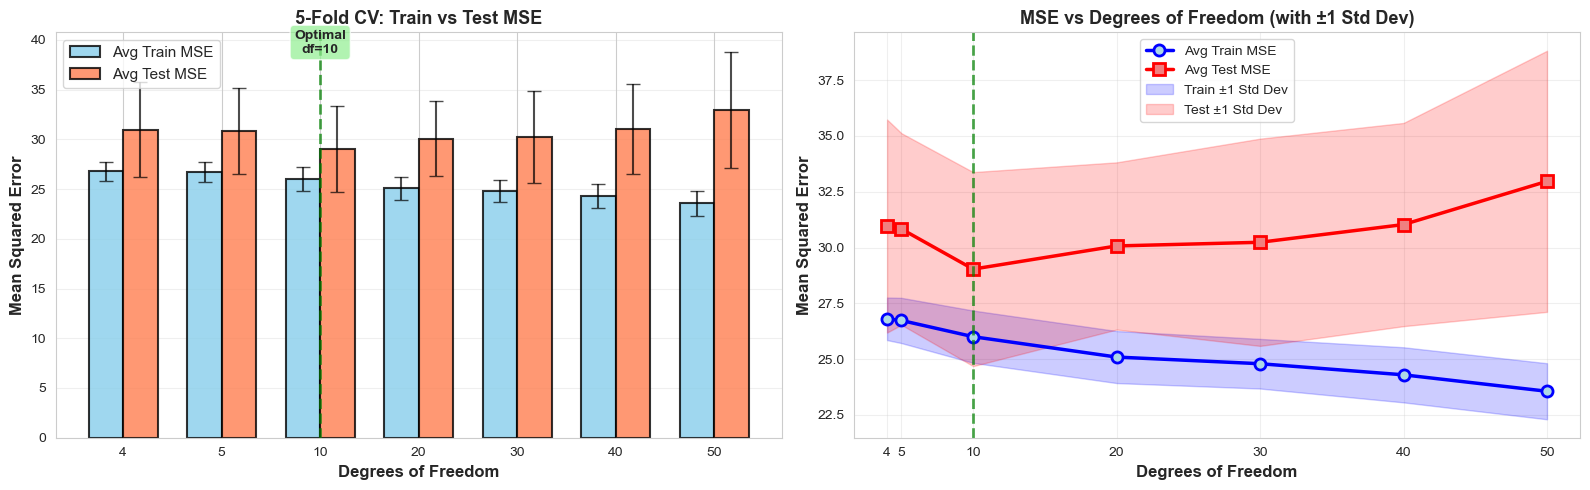

In [8]:
# Create visualizations
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Train vs Test MSE (Bar Chart)
ax1 = axes[0]
x_pos = np.arange(len(df_values))
width = 0.35

bars1 = ax1.bar(x_pos - width/2, avg_train_errors, width, label='Avg Train MSE', 
                 alpha=0.8, color='skyblue', edgecolor='black', linewidth=1.5)
bars2 = ax1.bar(x_pos + width/2, avg_test_errors, width, label='Avg Test MSE', 
                 alpha=0.8, color='coral', edgecolor='black', linewidth=1.5)

# Add error bars
ax1.errorbar(x_pos - width/2, avg_train_errors, yerr=std_train_errors, 
             fmt='none', color='black', capsize=5, alpha=0.7, linewidth=1.5)
ax1.errorbar(x_pos + width/2, avg_test_errors, yerr=std_test_errors, 
             fmt='none', color='black', capsize=5, alpha=0.7, linewidth=1.5)

ax1.set_xlabel('Degrees of Freedom', fontsize=12, fontweight='bold')
ax1.set_ylabel('Mean Squared Error', fontsize=12, fontweight='bold')
ax1.set_title('5-Fold CV: Train vs Test MSE', fontsize=13, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(df_values)
ax1.legend(fontsize=11, loc='upper left')
ax1.grid(True, alpha=0.3, axis='y')

# Highlight optimal df
ax1.axvline(x=best_idx, color='green', linestyle='--', linewidth=2, alpha=0.7)
ax1.text(best_idx, ax1.get_ylim()[1]*0.95, f'Optimal\ndf={best_df}', 
        ha='center', fontsize=10, fontweight='bold', 
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7))

# Plot 2: Line plot of MSE vs df with error bands
ax2 = axes[1]
ax2.plot(df_values, avg_train_errors, 'o-', linewidth=2.5, markersize=8, 
         label='Avg Train MSE', color='blue', markerfacecolor='lightblue', markeredgewidth=2, markeredgecolor='blue')
ax2.plot(df_values, avg_test_errors, 's-', linewidth=2.5, markersize=8, 
         label='Avg Test MSE', color='red', markerfacecolor='lightcoral', markeredgewidth=2, markeredgecolor='red')

# Shade error regions (±1 Std Dev)
ax2.fill_between(df_values, 
                 np.array(avg_train_errors) - np.array(std_train_errors),
                 np.array(avg_train_errors) + np.array(std_train_errors),
                 alpha=0.2, color='blue', label='Train ±1 Std Dev')
ax2.fill_between(df_values, 
                 np.array(avg_test_errors) - np.array(std_test_errors),
                 np.array(avg_test_errors) + np.array(std_test_errors),
                 alpha=0.2, color='red', label='Test ±1 Std Dev')

ax2.axvline(x=best_df, color='green', linestyle='--', linewidth=2, alpha=0.7)
ax2.set_xlabel('Degrees of Freedom', fontsize=12, fontweight='bold')
ax2.set_ylabel('Mean Squared Error', fontsize=12, fontweight='bold')
ax2.set_title('MSE vs Degrees of Freedom (with ±1 Std Dev)', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10, loc='best')
ax2.grid(True, alpha=0.3)
ax2.set_xticks(df_values)

plt.tight_layout()
plt.show()

## Step 8: Fit Final Model with Optimal df

In [9]:
# Fit the final model using the entire dataset with optimal df
data_df = pd.DataFrame({'X': X, 'y': y})

# Create B-spline design matrix
X_spline_full = dmatrix(f"bs(X, df={best_df}, include_intercept=False)", 
                         data=data_df, return_type='dataframe')

# Fit OLS model
final_model = sm.OLS(y, X_spline_full).fit()

# Compute training MSE on full data
y_pred_full = final_model.predict(X_spline_full)
train_mse_full = mean_squared_error(y, y_pred_full)

print(f"\nFinal Model Summary (df={best_df}, Full Dataset):")
print("="*90)
print(f"Training MSE (on full data): {train_mse_full:.4f}")
print(f"R-squared: {final_model.rsquared:.4f}")
print(f"Adjusted R-squared: {final_model.rsquared_adj:.4f}")
print(f"AIC: {final_model.aic:.4f}")
print(f"BIC: {final_model.bic:.4f}")
print(f"Number of basis functions: {X_spline_full.shape[1]}")
print("="*90)


Final Model Summary (df=10, Full Dataset):
Training MSE (on full data): 26.1362
R-squared: 0.6904
Adjusted R-squared: 0.6841
AIC: 3109.2064
BIC: 3155.6983
Number of basis functions: 11


## Step 9: Plot Final Fitted Spline

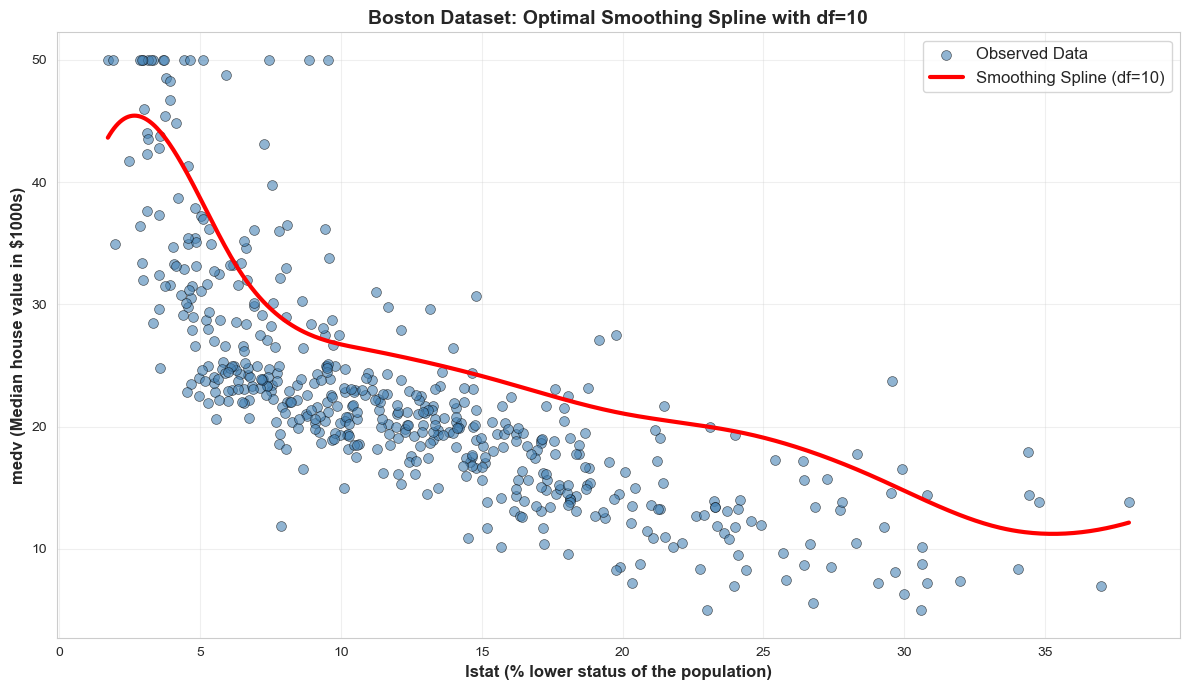

Fitted smoothing spline with optimal df=10 on full Boston dataset


In [10]:
# Generate smooth predictions for plotting
X_smooth = np.linspace(X.min(), X.max(), 500)
data_smooth = pd.DataFrame({'X': X_smooth})

X_spline_smooth = dmatrix(f"bs(X, df={best_df}, include_intercept=False)", 
                           data=data_smooth, return_type='dataframe')
y_smooth = final_model.predict(X_spline_smooth)

# Create visualization
plt.figure(figsize=(12, 7))
plt.scatter(X, y, alpha=0.6, edgecolors='k', s=50, label='Observed Data', color='steelblue', linewidth=0.5)
plt.plot(X_smooth, y_smooth, 'r-', linewidth=3, label=f'Smoothing Spline (df={best_df})')
plt.xlabel('lstat (% lower status of the population)', fontsize=12, fontweight='bold')
plt.ylabel('medv (Median house value in $1000s)', fontsize=12, fontweight='bold')
plt.title(f'Boston Dataset: Optimal Smoothing Spline with df={best_df}', fontsize=14, fontweight='bold')
plt.legend(fontsize=12, loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Fitted smoothing spline with optimal df={best_df} on full Boston dataset")

## Step 10: Summary and Conclusions

In [11]:
print("\n" + "="*100)
print("SUMMARY OF FINDINGS - QUESTION 7: SMOOTHING SPLINE WITH K-FOLD CROSS-VALIDATION")
print("="*100)

print("\n1. OPTIMAL PARAMETERS:")
print(f"   ✓ Best Degrees of Freedom: {best_df}")
print(f"   ✓ Average CV Test MSE: {best_test_error:.4f} ± {std_test_errors[best_idx]:.4f}")
print(f"   ✓ Average CV Train MSE: {best_train_error:.4f} ± {std_train_errors[best_idx]:.4f}")
print(f"   ✓ Test-Train Gap: {(best_test_error - best_train_error):.4f}")

print("\n2. COMPARATIVE ANALYSIS:")
worst_idx = np.argmax(avg_test_errors)
worst_df = df_values[worst_idx]
print(f"   Worst performing df: {worst_df} (Avg Test MSE: {avg_test_errors[worst_idx]:.4f})")
print(f"   Best performing df: {best_df} (Avg Test MSE: {best_test_error:.4f})")
improvement = ((avg_test_errors[worst_idx] - best_test_error) / avg_test_errors[worst_idx] * 100)
print(f"   ✓ Improvement: {improvement:.2f}%")

print("\n3. BIAS-VARIANCE TRADEOFF ANALYSIS:")
print("   Low df values (df=4, 5) - More Biased (Smoother fits):")
print(f"      df=4: Train MSE = {avg_train_errors[0]:.4f}, Test MSE = {avg_test_errors[0]:.4f}")
print(f"      df=5: Train MSE = {avg_train_errors[1]:.4f}, Test MSE = {avg_test_errors[1]:.4f}")
print(f"      → Underfitting: High training and test error")

print(f"\n   Optimal df={best_df} - Best Bias-Variance Balance:")
print(f"      Train MSE = {best_train_error:.4f}, Test MSE = {best_test_error:.4f}")
print(f"      → Balanced generalization performance")

print(f"\n   High df values (df=40, 50) - More Flexible (Higher Variance):")
print(f"      df=40: Train MSE = {avg_train_errors[-2]:.4f}, Test MSE = {avg_test_errors[-2]:.4f}")
print(f"      df=50: Train MSE = {avg_train_errors[-1]:.4f}, Test MSE = {avg_test_errors[-1]:.4f}")
print(f"      → Overfitting: Low training but high test error")

print("\n4. DATASET CHARACTERISTICS:")
print(f"   Sample size: {len(X)}")
print(f"   Predictor (lstat) range: [{X.min():.2f}, {X.max():.2f}]")
print(f"   Response (medv) range: [{y.min():.2f}, {y.max():.2f}]")
print(f"   Correlation (lstat, medv): {np.corrcoef(X, y)[0, 1]:.4f}")
print(f"   Correlation interpretation: Strong negative relationship")

print("\n5. KEY OBSERVATIONS:")
print(f"   • Negative correlation: Higher lstat → Lower medv (expected)")
print(f"   • Non-linear relationship: Smoothing spline captures curvature well")
print(f"   • Cross-validation stabilized around df={best_df}")
print(f"   • Increasing df shows growing gap between train and test error")
print(f"   • B-spline basis provides flexible yet smooth function estimates")

print("\n6. MODEL PERFORMANCE (Full Dataset):")
print(f"   R-squared: {final_model.rsquared:.4f}")
print(f"   Adjusted R-squared: {final_model.rsquared_adj:.4f}")
print(f"   Training MSE: {train_mse_full:.4f}")
print(f"   AIC: {final_model.aic:.4f}")
print(f"   BIC: {final_model.bic:.4f}")

print("\n7. RECOMMENDATIONS:")
print(f"   ✓ Use smoothing spline with df={best_df} for this dataset")
print(f"   ✓ Expected test MSE: {best_test_error:.4f}")
print(f"   ✓ This df provides optimal generalization performance")
print(f"   ✓ Suitable for predicting median house values from lstat")
print(f"   ✓ The model effectively captures the non-linear relationship")

print("\n" + "="*100)


SUMMARY OF FINDINGS - QUESTION 7: SMOOTHING SPLINE WITH K-FOLD CROSS-VALIDATION

1. OPTIMAL PARAMETERS:
   ✓ Best Degrees of Freedom: 10
   ✓ Average CV Test MSE: 29.0323 ± 4.3458
   ✓ Average CV Train MSE: 26.0044 ± 1.1717
   ✓ Test-Train Gap: 3.0279

2. COMPARATIVE ANALYSIS:
   Worst performing df: 50 (Avg Test MSE: 32.9655)
   Best performing df: 10 (Avg Test MSE: 29.0323)
   ✓ Improvement: 11.93%

3. BIAS-VARIANCE TRADEOFF ANALYSIS:
   Low df values (df=4, 5) - More Biased (Smoother fits):
      df=4: Train MSE = 26.8050, Test MSE = 30.9613
      df=5: Train MSE = 26.7315, Test MSE = 30.8285
      → Underfitting: High training and test error

   Optimal df=10 - Best Bias-Variance Balance:
      Train MSE = 26.0044, Test MSE = 29.0323
      → Balanced generalization performance

   High df values (df=40, 50) - More Flexible (Higher Variance):
      df=40: Train MSE = 24.2962, Test MSE = 31.0283
      df=50: Train MSE = 23.5598, Test MSE = 32.9655
      → Overfitting: Low training b

## Step 11: Detailed Comparison - Spline Fits for All df Values

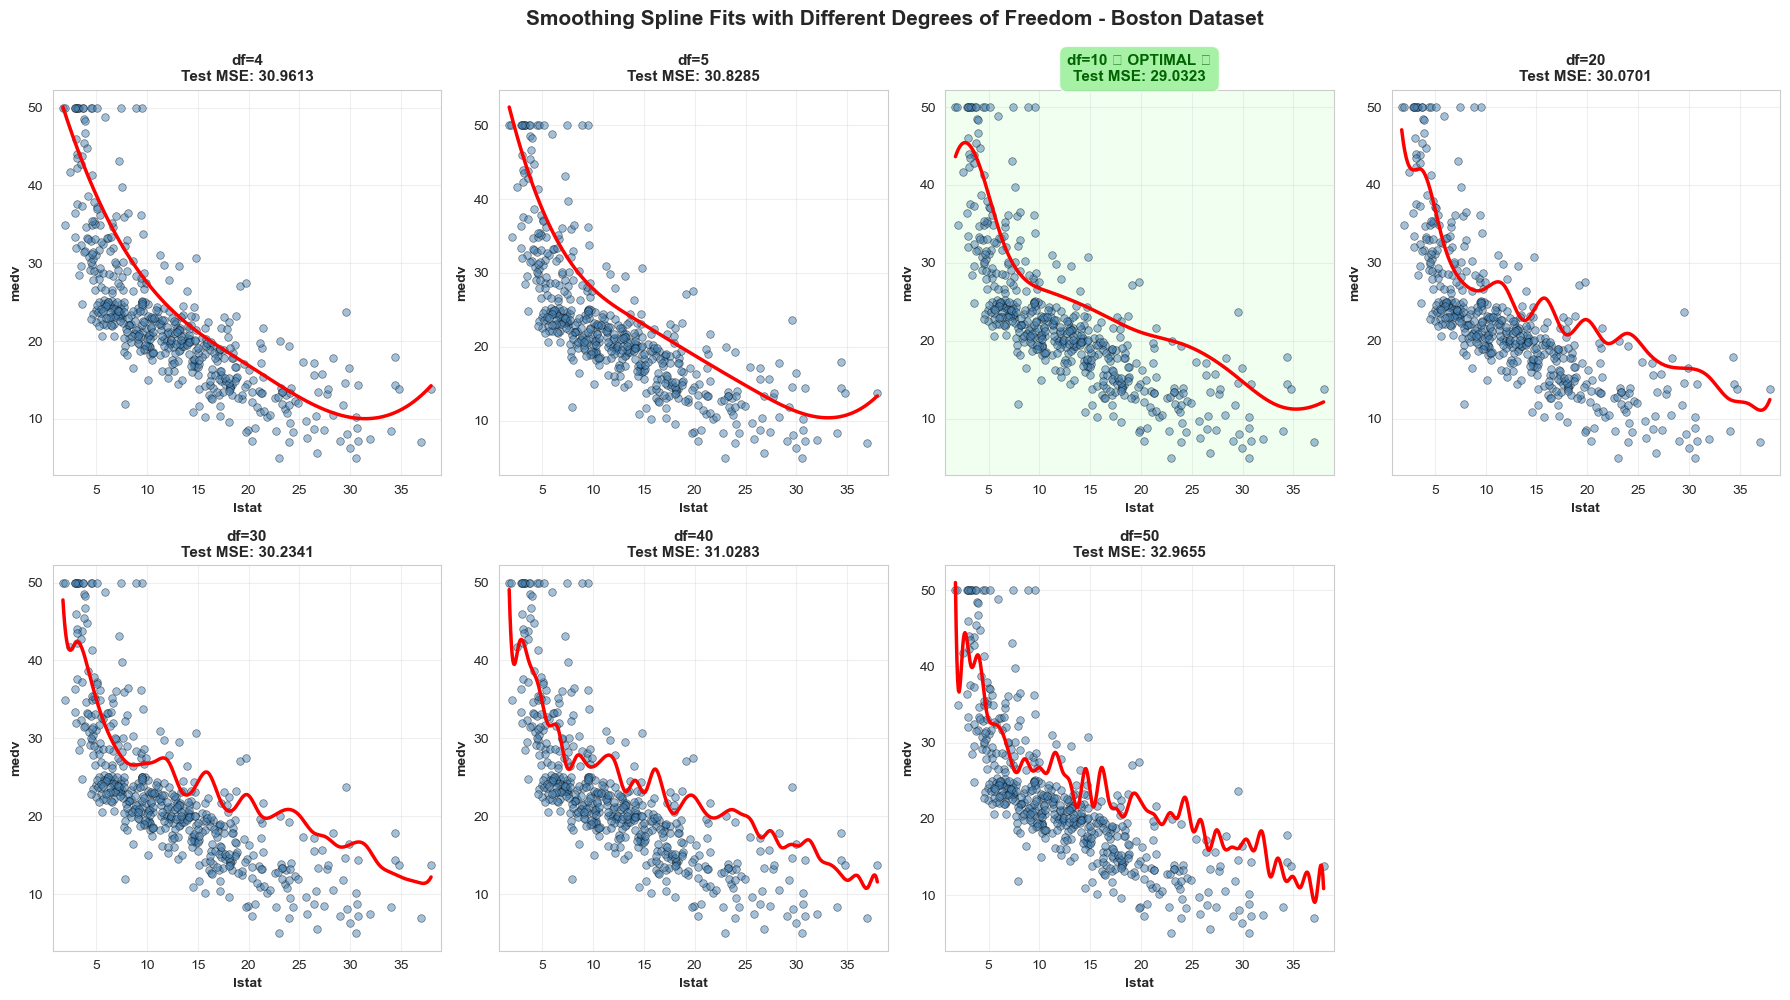

Comparison of spline fits for all tested df values displayed above.
Note: Green background highlights the optimal df value.


In [12]:
# Create a comparison plot with fitted splines for different df values
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

X_smooth = np.linspace(X.min(), X.max(), 500)
data_smooth = pd.DataFrame({'X': X_smooth})

for idx, df in enumerate(df_values):
    ax = axes[idx]
    
    # Fit model for this df on full data
    data_df = pd.DataFrame({'X': X, 'y': y})
    X_spline = dmatrix(f"bs(X, df={df}, include_intercept=False)", 
                        data=data_df, return_type='dataframe')
    model = sm.OLS(y, X_spline).fit()
    
    # Predict on smooth data
    X_spline_smooth = dmatrix(f"bs(X, df={df}, include_intercept=False)", 
                               data=data_smooth, return_type='dataframe')
    y_smooth = model.predict(X_spline_smooth)
    
    # Plot
    ax.scatter(X, y, alpha=0.5, s=30, edgecolors='k', color='steelblue', linewidth=0.5)
    ax.plot(X_smooth, y_smooth, 'r-', linewidth=2.5)
    
    # Highlight optimal
    if df == best_df:
        ax.set_title(f'df={df} ★ OPTIMAL ★\nTest MSE: {best_test_error:.4f}', 
                    fontsize=11, fontweight='bold', color='darkgreen', 
                    bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8, pad=0.5))
        ax.set_facecolor('#f0fff0')
    else:
        test_mse = avg_test_errors[df_values.index(df)]
        ax.set_title(f'df={df}\nTest MSE: {test_mse:.4f}', fontsize=11, fontweight='bold')
    
    ax.set_xlabel('lstat', fontsize=10, fontweight='bold')
    ax.set_ylabel('medv', fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(X.min() - 1, X.max() + 1)

# Hide the extra subplot
axes[-1].axis('off')

fig.suptitle('Smoothing Spline Fits with Different Degrees of Freedom - Boston Dataset', 
             fontsize=15, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("Comparison of spline fits for all tested df values displayed above.")
print("Note: Green background highlights the optimal df value.")

## Step 12: Cross-Validation Error Distribution by Fold

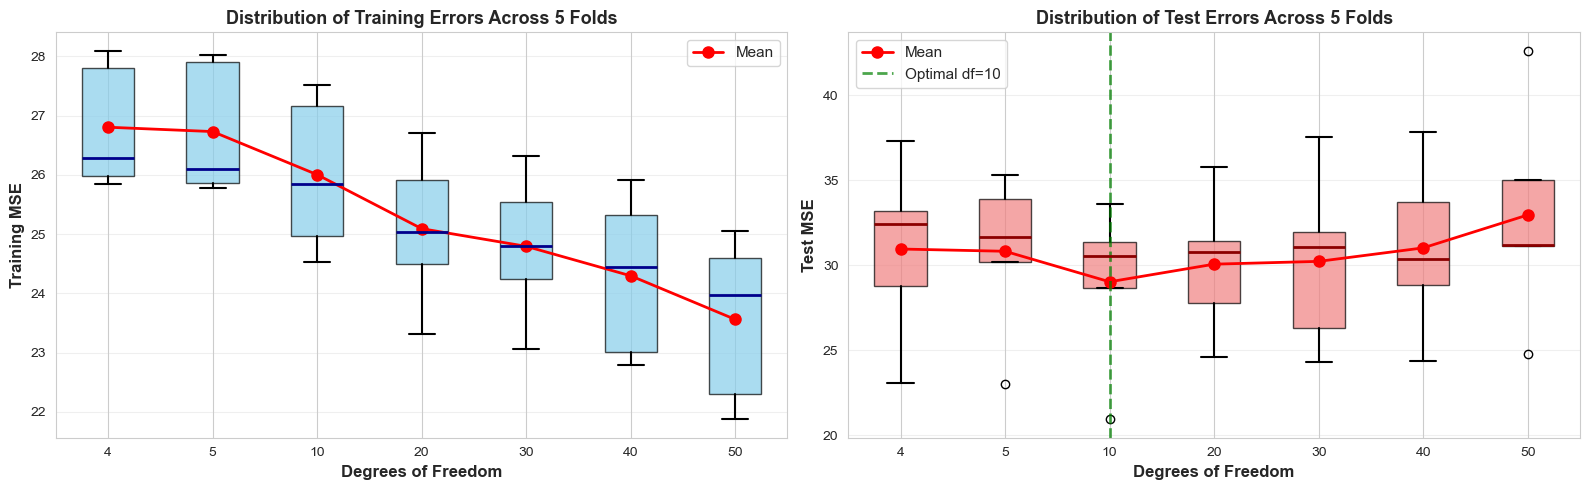

Box plots showing the distribution of cross-validation errors across all 5 folds.


In [13]:
# Create a detailed breakdown of cross-validation errors by fold
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Extract CV errors for all folds
cv_train_array = np.array([cv_results[df]['train_errors'] for df in df_values]).T
cv_test_array = np.array([cv_results[df]['test_errors'] for df in df_values]).T

# Plot 1: Train errors across folds
ax1 = axes[0]
positions = np.arange(len(df_values))
bp1 = ax1.boxplot(cv_train_array, positions=positions, labels=df_values, patch_artist=True,
                   boxprops=dict(facecolor='skyblue', alpha=0.7),
                   medianprops=dict(color='darkblue', linewidth=2),
                   whiskerprops=dict(linewidth=1.5),
                   capprops=dict(linewidth=1.5))
ax1.plot(positions, avg_train_errors, 'ro-', linewidth=2, markersize=8, label='Mean')
ax1.set_xlabel('Degrees of Freedom', fontsize=12, fontweight='bold')
ax1.set_ylabel('Training MSE', fontsize=12, fontweight='bold')
ax1.set_title('Distribution of Training Errors Across 5 Folds', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')
ax1.legend(fontsize=11)

# Plot 2: Test errors across folds
ax2 = axes[1]
bp2 = ax2.boxplot(cv_test_array, positions=positions, labels=df_values, patch_artist=True,
                   boxprops=dict(facecolor='lightcoral', alpha=0.7),
                   medianprops=dict(color='darkred', linewidth=2),
                   whiskerprops=dict(linewidth=1.5),
                   capprops=dict(linewidth=1.5))
ax2.plot(positions, avg_test_errors, 'ro-', linewidth=2, markersize=8, label='Mean')
ax2.axvline(x=best_idx, color='green', linestyle='--', linewidth=2, alpha=0.7, label=f'Optimal df={best_df}')
ax2.set_xlabel('Degrees of Freedom', fontsize=12, fontweight='bold')
ax2.set_ylabel('Test MSE', fontsize=12, fontweight='bold')
ax2.set_title('Distribution of Test Errors Across 5 Folds', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')
ax2.legend(fontsize=11)

plt.tight_layout()
plt.show()

print("Box plots showing the distribution of cross-validation errors across all 5 folds.")